In [13]:
!pip install python-igraph

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 22.0 MB/s eta 0:00:00



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Number of nodes: 14666
Number of edges: 80070
Average Clustering Coefficient: 0.3117


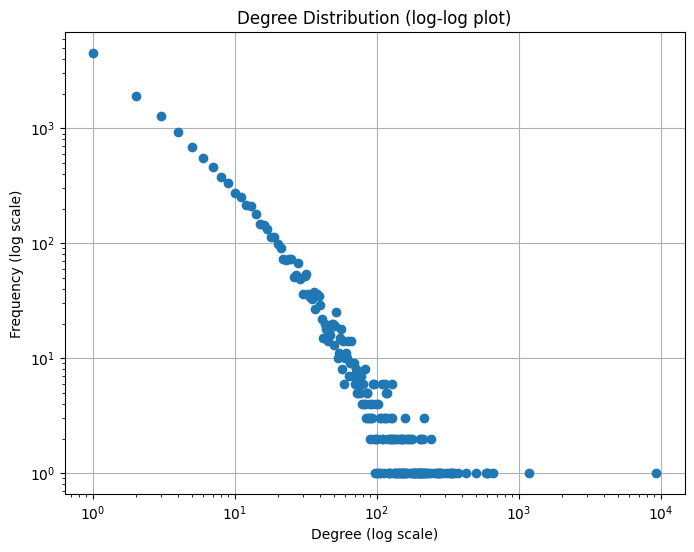

In [ ]:
# Install igraph
# pip install python-igraph

import igraph as ig
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the network
file_path = r"C:\Users\kdivy\OneDrive\Desktop\COMP ANA HT DATA\ASSIGNMENT-5\Human-PPI.txt"

# Read data
ppi_data = pd.read_csv(file_path, sep='\t', skiprows=1, names=["Protein1", "Protein2"])

# Build graph
g = ig.Graph.TupleList(ppi_data.itertuples(index=False), directed=False)

print(f"Number of nodes: {g.vcount()}")
print(f"Number of edges: {g.ecount()}")

# Degree and Clustering Coefficient
degrees = g.degree()
clustering_coeffs = g.transitivity_local_undirected(vertices=None, mode="zero")

# Average clustering coefficient
average_clustering = g.transitivity_avglocal_undirected()
print(f"Average Clustering Coefficient: {average_clustering:.4f}")

# Degree distribution on log-log plot
degree_counts = np.bincount(degrees)
degree_values = np.arange(len(degree_counts))

# Avoid zero entries for log-log plot
nonzero_indices = degree_counts > 0

plt.figure(figsize=(8,6))
plt.loglog(degree_values[nonzero_indices], degree_counts[nonzero_indices], marker='o', linestyle='None')
plt.xlabel('Degree (log scale)')
plt.ylabel('Frequency (log scale)')
plt.title('Degree Distribution (log-log plot)')
plt.grid(True)
plt.show()


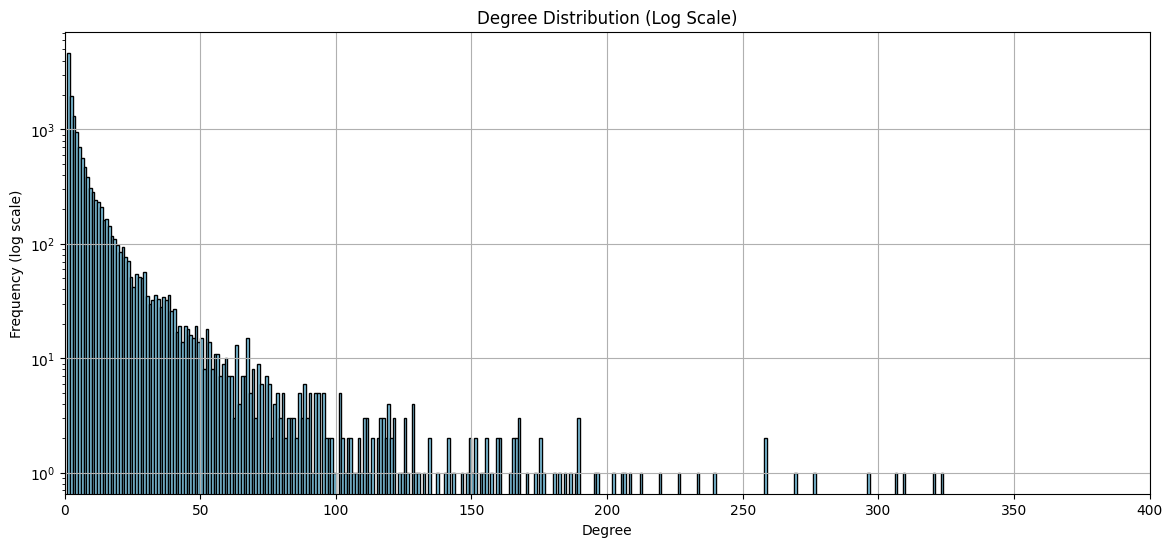

Node metrics saved to 'ppi_node_metrics.csv'


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load the network
file_path = r"C:\Users\kdivy\OneDrive\Desktop\COMP ANA HT DATA\ASSIGNMENT-5\Human-PPI.txt"

# Read the file correctly
ppi_data = pd.read_csv(file_path, sep='\t', skiprows=1, names=["Protein1", "Protein2"])

# Build the graph
G = nx.Graph()
for index, row in ppi_data.iterrows():
    G.add_edge(row['Protein1'], row['Protein2'])

# Compute degrees and clustering
degree_dict = dict(G.degree())
degrees = list(degree_dict.values())
clustering_dict = nx.clustering(G)

# Plot degree distribution
plt.figure(figsize=(14,6))
plt.hist(degrees, bins=range(1, max(degrees)+1), color='skyblue', edgecolor='black', log=True)
plt.title('Degree Distribution (Log Scale)')
plt.xlabel('Degree')
plt.ylabel('Frequency (log scale)')
plt.grid(True)
plt.xlim(0, 400)
plt.show()

# Save degree + clustering to CSV
node_metrics = pd.DataFrame({
    'Protein': list(degree_dict.keys()),
    'Degree': degrees,
    'ClusteringCoefficient': [clustering_dict[node] for node in degree_dict.keys()]
})

# Save to CSV (in same folder as script, or provide full path)
node_metrics.to_csv('ppi_node_metrics.csv', index=False)
print("Node metrics saved to 'ppi_node_metrics.csv'")


In [9]:
pip install networkx pandas matplotlib scipy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Protein list 1 - Total pairs found: 1176
Protein list 2 - Total pairs found: 435

Wilcoxon rank-sum test result:
Statistic = 0.4278, p-value = 6.6883e-01


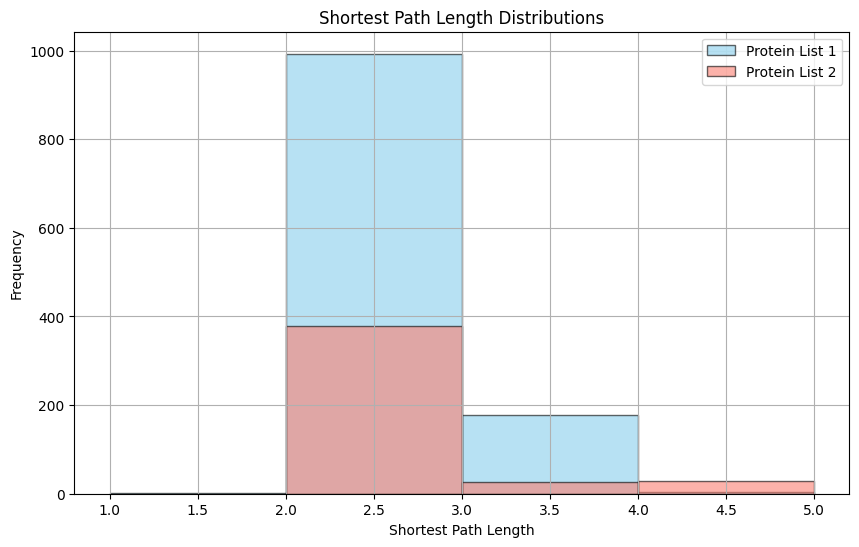

In [ ]:
import itertools

protein_list1 = pd.read_csv('protein-list1.txt', header=None)[0].tolist()
protein_list2 = pd.read_csv('protein-list2.txt', header=None)[0].tolist()

def compute_shortest_paths(protein_list, graph):
    path_lengths = []
    for u, v in itertools.combinations(protein_list, 2):
        if graph.has_node(u) and graph.has_node(v):
            try:
                length = nx.shortest_path_length(graph, source=u, target=v)
                path_lengths.append(length)
            except nx.NetworkXNoPath:
                pass  # Ignore if no path
    return path_lengths
# Compute for both lists
path_lengths1 = compute_shortest_paths(protein_list1, G)
path_lengths2 = compute_shortest_paths(protein_list2, G)

print(f"Protein list 1 - Total pairs found: {len(path_lengths1)}")
print(f"Protein list 2 - Total pairs found: {len(path_lengths2)}")

# Statistical Test (Wilcoxon rank-sum test)
statistic, p_value = stats.ranksums(path_lengths1, path_lengths2)
print(f"\nWilcoxon rank-sum test result:")
print(f"Statistic = {statistic:.4f}, p-value = {p_value:.4e}")

# Plot distributions
plt.figure(figsize=(10,6))
plt.hist(path_lengths1, bins=range(1, max(path_lengths1+path_lengths2)+1), 
         alpha=0.6, label='Protein List 1', color='skyblue', edgecolor='black')
plt.hist(path_lengths2, bins=range(1, max(path_lengths1+path_lengths2)+1), 
         alpha=0.6, label='Protein List 2', color='salmon', edgecolor='black')
plt.xlabel('Shortest Path Length')
plt.ylabel('Frequency')
plt.title('Shortest Path Length Distributions')
plt.legend()
plt.grid(True)
plt.show()
